In [1]:
%load_ext autoreload
%autoreload 2

# Project: Image segmentation

## Goal

The goal in this project is to create a tissue segmentation method, based on the techniques you have seen so far. This method should generalize well to different images. We will be using the same images as in the segmentation exercises.

Similar to project 1, your assignment is to investigate of what method or combination of methods is most suitable for doing this. In this investigation, you should explain the choices you are making, for example by referring to what you studied in class, showing plots etc.

There isn't one correct answer for the project. Your reasoning should show the reader that you understand the methods you studied, how to apply them to tissue segmentation and interpret the results. Consider these two example answers:

- (Poor) "We tried all combinations of features, and features A and B gave the best error, therefore you should always use features A and B"
- (Good) "Based on the scatterplots, we saw that features A and B, and features B and C, provided a good separation of the classes. We created learning curves for these two combinations. For features A and B, the error was lower for all training sizes. We then used the classifier trained on 1000 samples to visualize the predicted mask next to the true mask. Here we can see that the classifier makes many errors for the skull pixels, because their appearance is similar to pixels inside the brain."

The assignment consists of two parts, as a first step there is preliminary guided project work, and as a second step you must investigate a suitable research question based on the methods you have developed. A research question based on the preliminary guided project work below, completing the programming tasks and answering the theory questions, is the minimal solution to this project. If this is done well and accompanied by a suitable report, this will be graded with a ‘sufficient’ grade. To achieve higher grades, you need to go beyond the minimal solution. You should use what you have implemented and the available data to come up with and answer a suitable research question. Write about this in your report.


## Deliverables
A completed version of this notebook, the documented python code that you developed, and a report describing your research question, results and analysis. The report is expected in a short, concise format. It focusses on your specific research questions, results and discussion. The lecturers already know the background, the data and the general methodology. Your report therefore does not need to include an introduction on the clinical problem nor explanations of the background of image registration. You do have to include your design choices and motivation thereof.

Aim to present your most important findings in the main body of the report and (if needed) any additional information in an appendix. The following report structure is suggested for the main body of the report:

1. Introduce research question and hypothesis with its motivation (0.5 page)
2. Study design: which data did you use, what are the requirements of your method,
why did you make certain choices. Be as complete as possible w.r.t. the components
of a study design. (0.5 page)
3. Method, experiments and results for each research question (2 pages)
4. Discussion section with analysis of the results. (1 page)
5. Contributions: a brief description by each group member of their activities in the project which can be used to to adjust individual grades to reflect a student’s (lack of) contribution to the group
6. If you use large language models (such as ChatGPT) in your course work, you are required to declare how and for what they were used and to include a reflection on the use of such tools.

The page lengths above are indications. You are free to adapt them, with the constraint of a maximum length of five pages for the first four items listed.

The report must be submitted as a single PDF file. The documented code must be submitted as a single archive file (e.g. zip or 7z) that is self-contained and can be used to reproduce the results in the report. 

Note that there is no single correct solution for the project. You have to demonstrate to the reader that you understand the methods that you have studied and can critically analyze the results of applying the methods. Below, you can find a set of assignments (guided project work) that will help you get started with the project work and, when correctly completed, will present you with a **minimal solution**. Solutions which go beyond these assignments are of course encouraged. Additionally, include the solutions to the preliminary guided project work within this notebook in the archive file. 

## Assessment
The rubric that will be used for assessment of the project work is given in [this table](https://github.com/tueimage/8BE030-MIA/blob/master/rubric.md). Please

## Preliminary guided project work
### 1. Creating datasets

**1. Create a dataset for all the images, but where the labels are based on a different task: white matter vs gray matter vs cerebrospinal fluid.**

In [4]:
import sys
sys.path.append("../code")
import segmentation_util as util
import segmentation as seg


dataset = {'X':[],
           'Y':[],
           'feature_labels':[]}

for patient in range(5):
    for slice in range(3):
        X,Y,feature_labels = util.create_dataset(patient+1, slice+1, 'brain')

        dataset['X'].append(X)
        dataset['Y'].append(Y)
        dataset['feature_labels'].append('feature_labels')



**2. Implement the missing functionality in `extract_features`. The final result should extract 5-10 features that you tried in the exercises, or created yourself, for a particular subject and slice.**

The added features are the following:

1. Gaussian Blur (sigma=1): We blurred the image to obtain low-frequency information about the neighbourhoods. We use a smaller sigma to capture more local context

2. Gaussian Blur (sigma=2): We blurred the image with a larger sigma to capture broader regional information (tissue position)

3. Sobel Edge Filter: We compute the spatial gradients of images to extract tissue edges (high-frequency information)

Each of the features is computed for both T1 and T2 images, totalling 6 new extracted features.

**3. Examine the (already implemented, but you might need to modify the location of the images it loads) function `create_dataset` which extracts the features for a several subjects and/or slices, and creates the labels (either for the brain/not brain task, or the tissue classification task). Create one training dataset for the tissue classification task.**

In [12]:
import numpy as np

X_all = []
Y_all = []
feature_labels = None

for patient in range(5):
    for slice in range(3):
        X,Y,labels = util.create_dataset(patient+1, slice+1, 'tissue')

        X_all.append(X)
        Y_all.append(Y)
        feature_labels = labels

X = np.concatenate(X_all, axis=0)
Y = np.concatenate(Y_all, axis=0)
Y = Y.flatten()

**4. Use `scatter_data` to look at the features you have. You can also look at PCA or subsets of the features. What can you say about the features?**

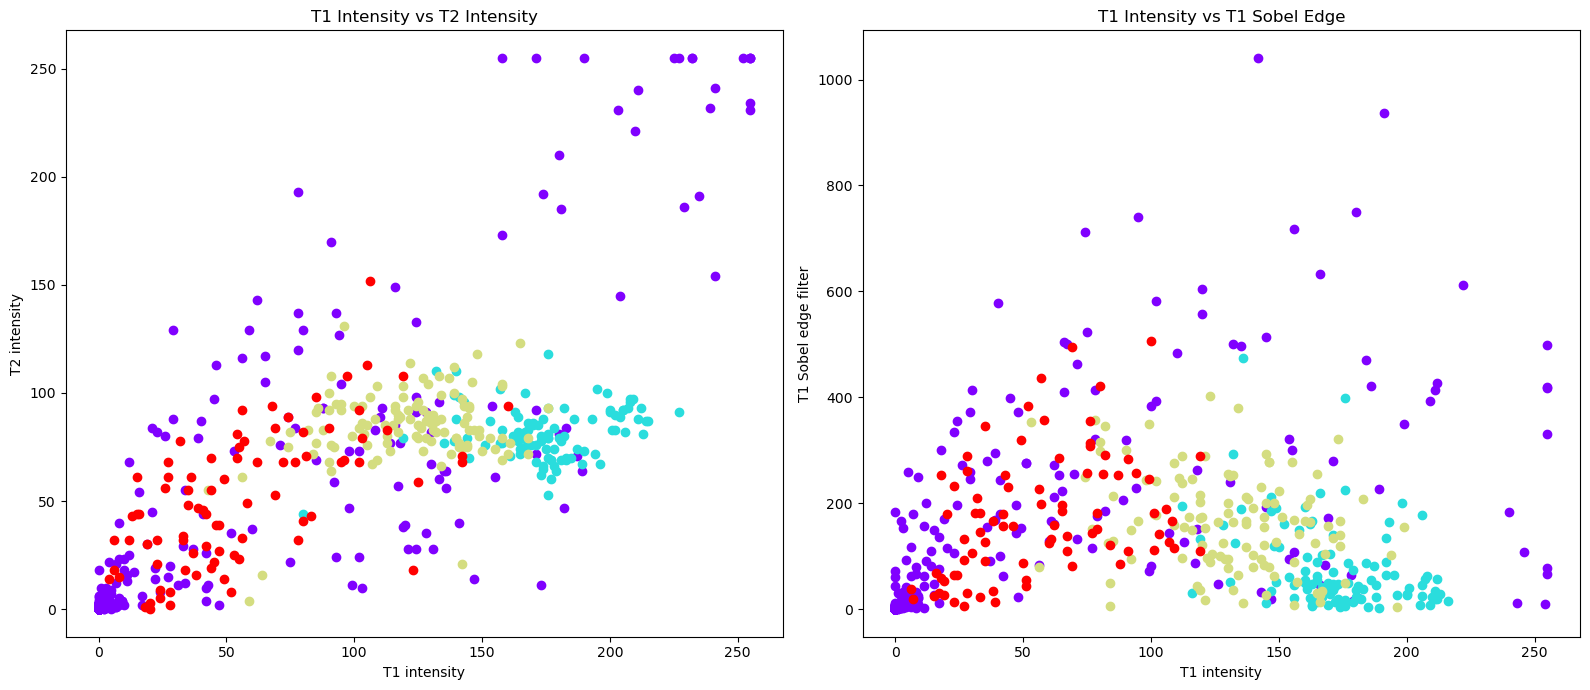

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
util.scatter_data(X, Y, feature0=0, feature1=1, ax=ax1)
ax1.set_title('T1 Intensity vs T2 Intensity')
ax1.set_xlabel(feature_labels[0])
ax1.set_ylabel(feature_labels[1])

# T1 Intensity vs T1 Sobel Edge Magnitude
util.scatter_data(X, Y, feature0=0, feature1=6, ax=ax2)
ax2.set_title('T1 Intensity vs T1 Sobel Edge')
ax2.set_xlabel(feature_labels[0])
ax2.set_ylabel(feature_labels[6])

plt.tight_layout()
plt.show()

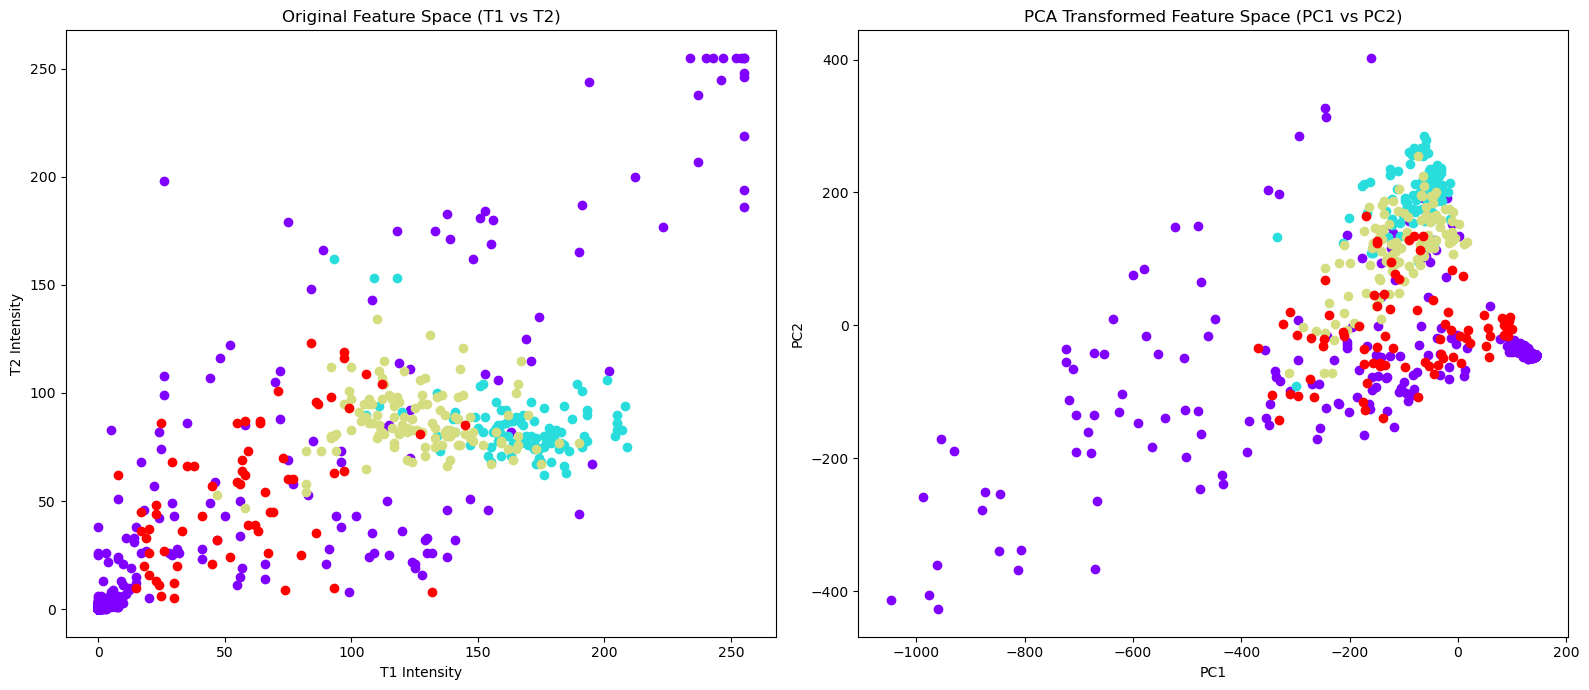

In [15]:
X_pca, v, w, fraction_variance = seg.mypca(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
util.scatter_data(X, Y, feature0=0, feature1=1, ax=ax1)
ax1.set_title('Original Feature Space (T1 vs T2)')
ax1.set_xlabel('T1 Intensity')
ax1.set_ylabel('T2 Intensity')

# PCA Results
util.scatter_data(X_pca, Y, feature0=0, feature1=1, ax=ax2)
ax2.set_title('PCA Transformed Feature Space (PC1 vs PC2)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

plt.tight_layout()
plt.show()

**5. In principle any type of processing you can apply to the image can be used to create more features. For example, if you enhance edges in the image, you can create a feature that provides information about whether that pixel is part of an edge or not. Think about the image processing techniques you learnt about in **8BB050** (for example, boundary extraction) and invent a new feature to add to your dataset. Implement it in a new function, for example `extract_myfeature` that has the image as input, and the feature vector as output.**
    
**You should aim for your feature to be different (not perfectly correlated) from the ones you already have. Note that you cannot use the ground-truth image to create features - you want to be able to extract the feature, even if ground truth is not available.**
    
**Your answer should include a description of the feature, the code to extract it, and a demonstration that shows it is different from the features you already have.**

In [34]:
from scipy import ndimage

def extract_entropy(im, window_size=5):
    """
    Extracts a local entropy texture feature from an image.
    Input:
        im - An NxM image matrix 
        window_size - The side length of the square neighborhood (must be odd)
    Output:
        feature_vector - A (N*M)x1 flattened vector representing local entropy
    """

    # if the image has a single value (i.e. all black) we return 0
    img_min, img_max = im.min(), im.max()
    if img_max == img_min:
        return np.zeros((im.shape[0]*im.shape[1], 1))
    
    # we first scale the image to 32 bins
    img_quantized = (((im-img_min) / (img_max-img_min))*31).astype(int)
    
    rows, cols = im.shape
    entropy_im = np.zeros_like(im, dtype=float)
    pad = window_size//2
    
    # borders are padded to make edges smoother
    padded_img = np.pad(img_quantized, pad, mode='reflect')
    

    num_pixels = window_size * window_size 
    
    for r in range(rows):
        for c in range(cols):
            # we first extract the local neighborhood patch
            patch = padded_img[r:r+window_size, c:c+window_size]
            
            # we count the number of times that the intensity appears in each patch
            counts = np.bincount(patch.ravel(), minlength=32)
            
            # Calculate probabilities (p_i) for bins present in the patch
            probs = counts/num_pixels
            probs = probs[probs>0]  # Filter out 0 values
            
            # Apply Shannon Entropy Formula: -sum(p*log2(p))
            entropy_im[r, c] = -np.sum(probs*np.log2(probs))
            
    mean_im = ndimage.uniform_filter(im.astype(float), size=window_size)
    sq_mean_im = ndimage.uniform_filter(im.astype(float)**2, size=window_size)
    std_im = np.sqrt(np.maximum(sq_mean_im - mean_im**2, 1e-5)) # avoid div by zero
    normalized_entropy = entropy_im / std_im

    # we flatten to match the project dataset format (N x 1)
    feature_vector = normalized_entropy.flatten().T.reshape(-1, 1)
    
    return feature_vector

def extract_distance(im):
    """
    Calculates the normalized Euclidean distance of each pixel from the intensity-based center of mass of the image
    """
    rows, cols = im.shape
    img = im.astype(float)

    # we create coordinate grids
    r_grid, c_grid = np.ogrid[:rows, :cols]
    
    # we compute the total intensity sum
    total_intensity = np.sum(img)

    # we calculate the intensity-weighted coordinates (Center of Mass)
    cx = np.sum(r_grid*img)/total_intensity
    cy = np.sum(c_grid*img)/total_intensity



    # we calculate Euclidean distance from center of mas for every pixel
    distance_im = np.sqrt((r_grid-cx)**2 + (c_grid-cy)**2)
    
    # we normalize between 0 and 1
    distance_im = distance_im /distance_im.max()
    
    return distance_im.flatten().reshape(-1, 1)

Correlation between [T1 intensity] and [T1 Center of Mass distance]: -0.7044
Correlation between [T2 intensity] and [T1 Center of Mass distance]: -0.5573
Correlation between [T1 Gaussian blur (sigma=1)] and [T1 Center of Mass distance]: -0.7341
Correlation between [T2 Gaussian blur (sigma=1)] and [T1 Center of Mass distance]: -0.6055
Correlation between [T1 Gaussian blur (sigma=3)] and [T1 Center of Mass distance]: -0.8067
Correlation between [T2 Gaussian blur (sigma=3)] and [T1 Center of Mass distance]: -0.7161
Correlation between [T1 Sobel edge filter] and [T1 Center of Mass distance]: -0.3784
Correlation between [T2 Sobel edge filter] and [T1 Center of Mass distance]: -0.2053


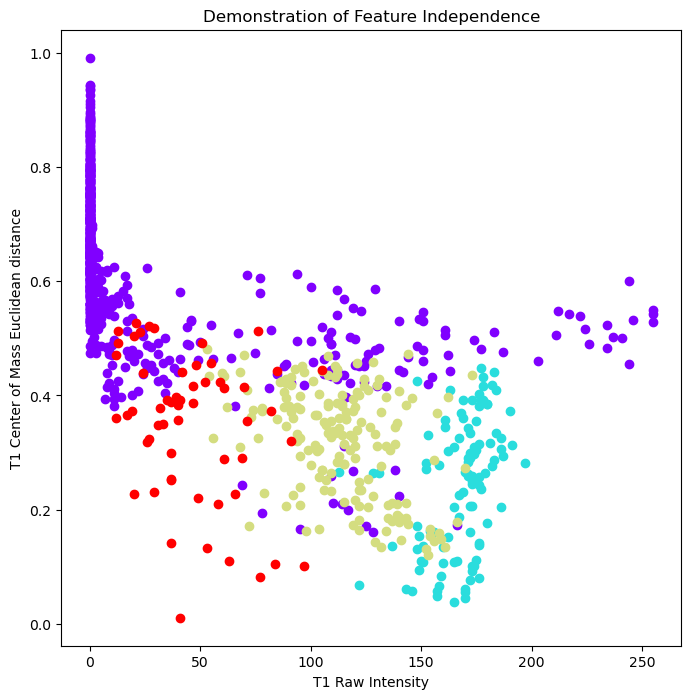

In [35]:
base_dir = '../data/dataset_brains/'
t1_img = plt.imread(base_dir + '1_1_t1.tif')

t1_distance = extract_distance(t1_img)

X, Y, feature_labels = util.create_dataset(1, 1, 'tissue')
X = np.concatenate((X, t1_distance), axis=1)
feature_labels = feature_labels + ('T1 Center of Mass distance',)

corr_matrix = np.corrcoef(X, rowvar=False)
for idx, label in enumerate(feature_labels[:-1]):
    correlation_value = corr_matrix[idx, -1] # we compare all features to the final column
    print(f"Correlation between [{label}] and [T1 Center of Mass distance]: {correlation_value:.4f}")

fig, ax = plt.subplots(figsize=(8, 8))

# Plot T1 Raw Intensity vs T1 Local Entropy
util.scatter_data(X, Y.flatten(), feature0=0, feature1=X.shape[1]-1, ax=ax)

ax.set_title('Demonstration of Feature Independence')
ax.set_xlabel('T1 Raw Intensity')
ax.set_ylabel('T1 Center of Mass Euclidean distance')
plt.show()

### 2. Model selection and generalization

**1. Use the `create_dataset` function to create a training set and a test set for the tissue segmentation task. Use the same slice, but different subjects for training and testing.**

In [43]:
# Training set
X_training = []
Y_training= []
feature_labels = None


X,Y,labels = util.create_dataset(1, 1, 'tissue')

X_training.append(X)
Y_training.append(Y)
feature_labels = labels

X_training = np.concatenate(X_training, axis=0)
Y_training = np.concatenate(Y_training, axis=0)
Y_training = Y_training.flatten()

# Test set
X_test = []
Y_test= []


X,Y,labels = util.create_dataset(5, 1, 'tissue')

X_test.append(X)
Y_test.append(Y)

X_test = np.concatenate(X_test, axis=0)
Y_test = np.concatenate(Y_test, axis=0)
Y_test= Y_test.flatten()

**2. Use these datasets to investigate using different features and different segmentation methods. You can use both classification error and dice overlap for evaluation, but since now there are four different classes (three tissues and background, you will need to use `dice_multiclass`.**

In [ ]:
import pandas as pd

feature_combinations = {
    "Raw Intensities Only": [0, 1],
    "Intensities + Blurs (Context)": [0, 1, 2, 3, 4, 5],
    "Intensities + Edges (Structure)": [0, 1, 6, 7],
    "Intensities + Center Distance (Geometry)": [0, 1, 8, 9],
    "All Extracted Features Combined": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
}

methods = {
    "1-NN Classifier": lambda train_x, train_y, test_x: seg.nn_classifier(train_x, train_y, test_x),
    "5-NN Classifier": lambda train_x, train_y, test_x: seg.knn_classifier(train_x, train_y, test_x, k=5),
    #"4-Mean Clustering": lambda train_x, train_y, test_x: seg.kmeans_clustering(train_x, train_y, test_x, k=4)

}

results = []
for feat_name, idx in feature_combinations.items():
    X_tr_sub = X_training[:, idx]
    X_te_sub = X_test[:, idx]
    X_tr_norm, X_te_norm = seg.normalize_data(X_tr_sub, X_te_sub)
    
    # we randomly subsample training pixels for faster execution
    num_samples = 3000
    ix = np.random.randint(X_tr_norm.shape[0], size=num_samples)
    X_tr_eval = X_tr_norm[ix, :]
    Y_tr_eval = Y_training[ix]
    
    for method_name, predict_func in methods.items():
        # Run inference
        Y_pred = predict_func(X_tr_eval, Y_tr_eval, X_te_norm).flatten()
        
        # Compute evaluation metrics
        err = util.classification_error(Y_test, Y_pred)
        dice = util.dice_multiclass(Y_test, Y_pred)
        
        results.append({
            "Feature Set": feat_name,
            "Method": method_name,
            "Class Error": err,
            "Mean Dice": dice
        })
        
df_summary = pd.DataFrame(results)
df_summary

,Feature Set,Method,Class Error,Mean Dice
0,Raw Intensities Only,1-NN Classifier,0.181389,0.656173
1,Raw Intensities Only,5-NN Classifier,0.164410,0.677670
2,Intensities + Blurs (Context),1-NN Classifier,0.164618,0.674592
3,Intensities + Blurs (Context),5-NN Classifier,0.151719,0.692386
4,Intensities + Edges (Structure),1-NN Classifier,0.150816,0.708890
5,Intensities + Edges (Structure),5-NN Classifier,0.131233,0.741072
6,Intensities + Center Distance (Geometry),1-NN Classifier,0.144948,0.709998
7,Intensities + Center Distance (Geometry),5-NN Classifier,0.126927,0.743300
8,All Extracted Features Combined,1-NN Classifier,0.132569,0.726644
9,All Extracted Features Combined,5-NN Classifier,0.115990,0.757203


**3. How do you decide what good choices are?  Document this process in a function you create yourself, which returns the best choices given two different subjects.**

In [50]:
def evaluate_segmentation_choices(train_subject, test_subject, slice, feature_combinations, methods):
    X_train, Y_train, feature_labels = util.create_dataset(train_subject, slice, 'tissue')
    X_test, Y_test, _ = util.create_dataset(test_subject, slice, 'tissue')
    
    Y_train = Y_train.flatten()
    Y_test = Y_test.flatten()

    results = []
    best_dice = -1.0
    best_config = {}

    for feat_name, idx in feature_combinations.items():
        X_tr_sub = X_training[:, idx]
        X_te_sub = X_test[:, idx]
        X_tr_norm, X_te_norm = seg.normalize_data(X_tr_sub, X_te_sub)
        
        # we randomly subsample training pixels for faster execution
        num_samples = 3000
        ix = np.random.randint(X_tr_norm.shape[0], size=num_samples)
        X_tr_eval = X_tr_norm[ix, :]
        Y_tr_eval = Y_training[ix]
        
        for method_name, predict_func in methods.items():
            # Run inference
            Y_pred = predict_func(X_tr_eval, Y_tr_eval, X_te_norm).flatten()
            
            # Compute evaluation metrics
            err = util.classification_error(Y_test, Y_pred)
            dice = util.dice_multiclass(Y_test, Y_pred)
            
            results.append({
                "Feature Set": feat_name,
                "Method": method_name,
                "Class Error": err,
                "Mean Dice": dice
            })
            
            if dice > best_dice:
                best_dice = dice
                best_config = {
                    "Feature Set": feat_name,
                    "Method": method_name,
                    "Mean Dice": dice,
                    "Class Error": err
                }

    df_summary = pd.DataFrame(results)
    
    return df_summary, best_config

In [52]:
feature_combinations = {
    "Raw Intensities Only": [0, 1],
    "Intensities + Blurs (Context)": [0, 1, 2, 3, 4, 5],
    "Intensities + Edges (Structure)": [0, 1, 6, 7],
    "Intensities + Center Distance (Geometry)": [0, 1, 8, 9],
    "All Extracted Features Combined": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
}

methods = {
    "1-NN Classifier": lambda train_x, train_y, test_x: seg.nn_classifier(train_x, train_y, test_x),
    "5-NN Classifier": lambda train_x, train_y, test_x: seg.knn_classifier(train_x, train_y, test_x, k=5),
    "4-Mean Clustering": lambda train_x, train_y, test_x: seg.kmeans_clustering(test_x, K=4)

}

summary, best_results = evaluate_segmentation_choices(1,5,1,feature_combinations, methods)

In [53]:
summary

,Feature Set,Method,Class Error,Mean Dice
0,Raw Intensities Only,1-NN Classifier,0.185903,0.647929
1,Raw Intensities Only,5-NN Classifier,0.161094,0.687235
2,Raw Intensities Only,4-Mean Clustering,0.852587,0.064356
3,Intensities + Blurs (Context),1-NN Classifier,0.163455,0.680109
4,Intensities + Blurs (Context),5-NN Classifier,0.151458,0.698188
5,Intensities + Blurs (Context),4-Mean Clustering,0.852587,0.064356
6,Intensities + Edges (Structure),1-NN Classifier,0.149115,0.710413
7,Intensities + Edges (Structure),5-NN Classifier,0.128090,0.742955
8,Intensities + Edges (Structure),4-Mean Clustering,0.852587,0.064356
9,Intensities + Center Distance (Geometry),1-NN Classifier,0.145174,0.704582


In [54]:
best_results

{'Feature Set': 'All Extracted Features Combined',
 'Method': '5-NN Classifier',
 'Mean Dice': np.float64(0.7624078588592833),
 'Class Error': np.float64(0.11342013888888888)}

**4. Repeat the above, but use a different subject for testing. Do your conclusions change or stay the same, why? What if you vary the slices?** 

In [55]:
summary, best_results = evaluate_segmentation_choices(1,4,1,feature_combinations, methods)
print('--- Changing testing subject ---')
print(best_results)

summary, best_results = evaluate_segmentation_choices(1,5,2,feature_combinations, methods)
print('--- Changing slice ---')
print(best_results)


--- Changing testing subject ---
{'Feature Set': 'All Extracted Features Combined', 'Method': '5-NN Classifier', 'Mean Dice': np.float64(0.7067072512739306), 'Class Error': np.float64(0.13725694444444445)}
--- Changing slice ---
{'Feature Set': 'Intensities + Edges (Structure)', 'Method': '5-NN Classifier', 'Mean Dice': np.float64(0.8008949272549926), 'Class Error': np.float64(0.10791666666666666)}


### 3. Combining different methods

1. Try the function `segmentation_combined_knn` on the tissue segmentation task (do not forget to combine the labels - look into e.g. majority voting). 
2. Design a method that combines (some) other methods you have learnt so far in `segmentation_mymethod`. Provide a motivation (based on what you know about the methods) of the choices that you made.
3. The script `segmentation_demo`, creates the results for several methods. This code is a bit slow, so it is not recommended to run it multiple times. (Also, you should not use all of these results to improve your method, since that means you are using the test data as the training data :) ). 
4. Run the script and look at the results. How does your method compare to the individual results? It is not required here that your method is always better! For example, you could select a subject where your method is the best, and a subject where your method is the worst, and explain what is happening in the images.
5. Discuss what other (combinations) methods could be suitable or not suitable for the task and why.

In [ ]:
%matplotlib inline
import sys
sys.path.append("../code")
from segmentation_project import segmentation_demo
segmentation_demo()

## Open-ended project work

Define and motivate one research question that you will investigate. This can be a question relating to a method (e.g. what is the impact of X on a particular method) or relating to the problem (e.g. does a specific method fail in specific cases). It can be based on what you have done above or take another direction.
It is recommended to get feedback on your research question from the teaching assistants.